In [17]:
import pandas as pd
import matplotlib.pyplot as plt


tourney_df = pd.read_pickle('pickle/tourney_w_brackets_df.p')

In [18]:
tourney_df = tourney_df[
    (tourney_df['Iowa'] > 2) 
    & (tourney_df['Purdue'] > 2)
    & (tourney_df['Arizona'] > 2)
    & (tourney_df['Illinois'] > 2)
    & (tourney_df['Duke'] > 2)
    & (tourney_df['Michigan'] > 2)
    & (tourney_df['Connecticut'] > 2)
    & (tourney_df['Tennessee'] > 2)
    ]
tourney_df.Probability = tourney_df.Probability / tourney_df.Probability.sum()

In [19]:
elite_eight = [] 
for team in tourney_df.columns[:32]:
    if tourney_df[team].min() >= 3:
        elite_eight.append(team)

elite_eight

['Arizona',
 'Connecticut',
 'Duke',
 'Illinois',
 'Iowa',
 'Michigan',
 'Purdue',
 'Tennessee']

In [20]:
dfs = []
all_labels = []
disp_titles = []


for team in elite_eight:
    print()
    print(team)
    sub_df = tourney_df.loc[tourney_df[team] == 6]
    grouped_df = sub_df[['Winner','Probability']].groupby('Winner').sum().sort_values('Probability', ascending = False)
    grouped_df['Win Probability'] = grouped_df['Probability']/grouped_df['Probability'].sum()
    grouped_df = grouped_df[['Win Probability']]
    grouped_df = grouped_df.loc[grouped_df['Win Probability'] > 0.05]
    other = 1.0 - grouped_df['Win Probability'].sum()
    if other > 0.0001:
        grouped_df.loc['Other'] = [other]
        
    dfs.append(grouped_df)
    labels = list(grouped_df.index)
    # lables = [_.replace(', ', ',\n') for _ in labels]
    all_labels += labels
    
    title = "If " + team + " wins it all."
    disp_titles.append(title)
    
    
    print(grouped_df['Win Probability'])
#     title = "Win probabilty if " + team + " wins it all."
#     ax.pie(grouped_df['Win Probability'], 
#            labels=grouped_df.index,
#            normalize=True,
#            autopct='%1.1f%%')
#     ax.set(ylabel='', title=title, aspect='equal')


Arizona
Winner
George Wright    1.0
Name: Win Probability, dtype: float64

Connecticut
Winner
Keith Schneider                0.517421
Mark Hurst                     0.343440
Keith Schneider, Mark Hurst    0.139139
Name: Win Probability, dtype: float64

Duke
Winner
Patrick Commers    0.390888
Tyler Krause       0.385284
Koy Kubasta        0.223829
Name: Win Probability, dtype: float64

Illinois
Winner
Patrick Commers                  0.303571
Keith Schneider                  0.278274
Tyler Krause                     0.218013
Keith Schneider, Tyler Krause    0.115626
Mark Hurst                       0.084516
Name: Win Probability, dtype: float64

Iowa
Winner
Tyler Krause                     0.242918
Mark Hurst                       0.167260
Keith Schneider                  0.152324
George Wright                    0.115105
Koy Kubasta                      0.113823
Patrick Commers                  0.099274
Keith Schneider, Tyler Krause    0.081414
Other                            0.02788

In [21]:
def get_color_list(n, step, floor, start=0):
    ang = 2 * pi * step/n
    R = sqrt(1/3)
    k = 1 - floor
    coords = [[sqrt(6) / 3, R * cos(i * ang), R * sin(i * ang)] for i in range(n)]
    M = [[sqrt(3)/3, -sqrt(3)/3, -sqrt(3)/3],
         [sqrt(3)/3, (3+sqrt(3))/6, -(3-sqrt(3))/6],
         [sqrt(3)/3,  -(3-sqrt(3))/6, (3+sqrt(3))/6]]
    colors = []
    for xyz in coords:
        new = [floor + k * sum(a*b for a, b in zip(xyz, row)) for row in M]
        colors.append(new)
        # floor += (1 - floor) / n
        # k = 1 - floor
        x, y, z = xyz        
    return colors

In [22]:
from math import sin, cos, sqrt, gcd, pi

seen = set()
final_labels = []
for label in all_labels:
    if label not in seen:
        final_labels.append(label)
        seen.add(label)
        
for label in sorted(seen):
    print(label)
        
n = len(final_labels)
step = 1
while gcd(step, n) > 1:
    step += 1
floor = 0.5
colors = get_color_list(n, step, floor, start=0)
color_dict = {label: color for label, color in zip(final_labels, colors)}

color_dict

George Wright
Keith Schneider
Keith Schneider, Mark Hurst
Keith Schneider, Mark Hurst, Tyler Krause
Keith Schneider, Tyler Krause
Koy Kubasta
Mark Hurst
Nathan Sanches
Other
Patrick Commers
Tyler Krause


{'George Wright': [0.5690355937288492, 0.9633731610262555, 0.6746980264314426],
 'Keith Schneider': [0.5053865353477194,
  0.8942498309553935,
  0.8074704148834346],
 'Mark Hurst': [0.514861092336115, 0.774788767475372, 0.9174569213750603],
 'Keith Schneider, Mark Hurst': [0.5944511597942411,
  0.6429180141695583,
  0.9697376072227479],
 'Patrick Commers': [0.7188874536606868,
  0.5405056034583297,
  0.9477137240675307],
 'Tyler Krause': [0.8486623298576937, 0.5000667521309855, 0.8583776991978682],
 'Koy Kubasta': [0.9425731821381702, 0.5344405097566877, 0.7300930892916895],
 'Keith Schneider, Tyler Krause': [0.9708039784454396,
  0.6327134511626413,
  0.6035893515784665],
 'Other': [0.9243916404212187, 0.7636846118158795, 0.5190305289494492],
 'Nathan Sanches': [0.818071757454288, 0.8857715736069993, 0.5032634501252602],
 'Keith Schneider, Mark Hurst, Tyler Krause': [0.6856001411662518,
  0.9602125887925714,
  0.5612940512277241]}

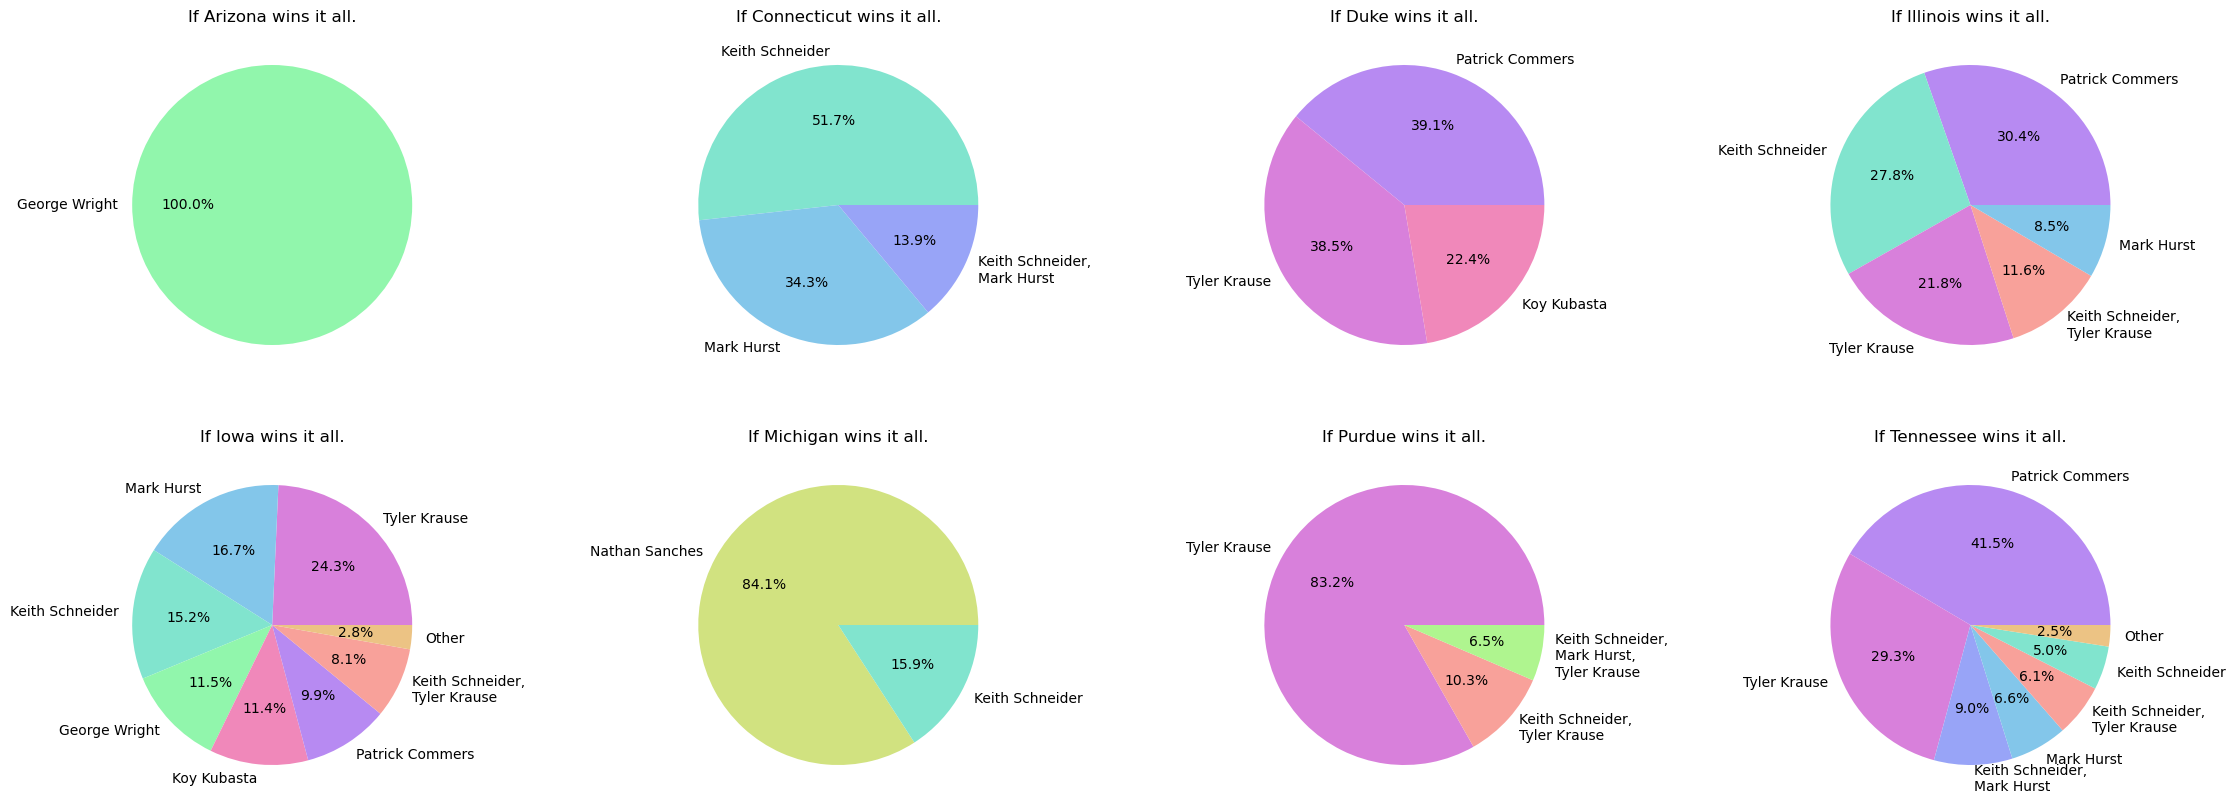

In [23]:
fig, axs = plt.subplots(2, 4, figsize = [28,10])

for ax, title, df in zip(axs.flatten(), disp_titles, dfs):
    labels=df.index
    colors = [color_dict[label] for label in labels]
    labels = [_.replace(', ', ',\n') for _ in labels]
    ax.pie(df['Win Probability'], 
           labels=labels,
           autopct='%1.1f%%',
           normalize=True,
           colors=colors)
    ax.set(ylabel='', title=title, aspect='equal')

plt.savefig('plots/who_wins_if_who_wins_elite_eight.png', dpi=300, bbox_inches='tight')
